# TEMEL ÖĞRENME ALGORİTMALARI DERSİ VİZE ÖDEVİ - METEHAN AYHAN

### Proje Konusu:
Bu projede, cilt kanseri ve kanser olmayan cilt resimleri kullanılarak bir yapay zeka modeli geliştirilmiştir. Bu model, verilen bir cilt resminin kanserli olup olmadığını tahmin etmek için derin öğrenme yöntemlerinden Convolutional Neural Networks (CNN) kullanmaktadır.

### Algoritma Açıklaması:
Kullanılan algoritma, CNN (Convolutional Neural Networks), görüntülerdeki özellikleri öğrenmeye yönelik bir yapay zeka modelidir. Bu ağ, görsel verilerle ilgili çok katmanlı öğrenme süreçlerinden geçer, her katmanda daha derin özellikler öğrenir. Bu projede, görüntülerden elde edilen özellikler sınıflandırmak için softmax aktivasyon fonksiyonu kullanılarak iki sınıf: Cancer ve Non_Cancer olarak etiketlenmiştir.

### Hazırlayan:
- METEHAN AYHAN

## Gerekli Paketleri import edelim

In [4]:
import cv2
import pandas as pd
import os #bu paket dosyaları okuma açma işlemi için..
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, Input, MaxPooling2D, Dropout, Reshape, BatchNormalization
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [5]:
#pip install opencv-python

In [6]:
labels=['Cancer','Non_Cancer']
img_path='Skin_Data/' #resimlerin yolunu verdik

In [7]:
os.listdir('Skin_Data')

['Cancer', 'Non_Cancer']

In [8]:
img_list=[] # önce boş liste oluşturduk resimleri okudukça içine atacağız.
label_list=[] #etiketler

for label in labels:
    for img_file in os.listdir(img_path+label):
        img_list.append(img_path+label+'/'+img_file)
        label_list.append(label)

In [9]:
df=pd.DataFrame({'img':img_list, 'label':label_list})
df.head()

,img,label
0,Skin_Data/Cancer/1007-1.jpg,Cancer
1,Skin_Data/Cancer/1010-01.JPG,Cancer
2,Skin_Data/Cancer/1012-2.JPG,Cancer
3,Skin_Data/Cancer/1031-1.jpg,Cancer
4,Skin_Data/Cancer/1051-3(94).jpg,Cancer


In [10]:
d={'Cancer':1,'Non_Cancer':0}
df['encode_label']=df['label'].map(d)
df.sample(5)

,img,label,encode_label
69,Skin_Data/Cancer/341-2.JPG,Cancer,1
67,Skin_Data/Cancer/311-1.JPG,Cancer,1
220,Skin_Data/Non_Cancer/436.JPG,Non_Cancer,0
153,Skin_Data/Non_Cancer/1810-01.JPG,Non_Cancer,0
198,Skin_Data/Non_Cancer/2389.JPG,Non_Cancer,0


## Normalize

In [12]:
# normalize edelim
x=[]
for img in df['img']:
    img=cv2.imread(img)   #resimleri okuma
    img=cv2.resize(img,(170,170))   #yeniden boyutlandırma 179x170 pixel
    img=img/255.0   #normalize
    x.append(img)

## Verisetini eğitim ve test olarak ayıralım

In [14]:
x=np.array(x) #sayı dizisine dönüştürüyoruz..

In [15]:
y=df['encode_label']

In [16]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=.20,random_state=42)

## CNN - Convolutional Neural Networks

In [18]:
model=Sequential()
model.add(Input(shape=(170,170,3)))
model.add(Conv2D(32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128))
model.add(Dense(2, activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
history= model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=15,verbose=1)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 439ms/step - accuracy: 0.6745 - loss: 5.7657 - val_accuracy: 0.2586 - val_loss: 1.0725
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 371ms/step - accuracy: 0.4951 - loss: 0.7613 - val_accuracy: 0.7931 - val_loss: 0.6121
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 368ms/step - accuracy: 0.7705 - loss: 0.6037 - val_accuracy: 0.7414 - val_loss: 0.8457
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 365ms/step - accuracy: 0.7533 - loss: 0.6477 - val_accuracy: 0.7586 - val_loss: 0.5489
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 386ms/step - accuracy: 0.7431 - loss: 0.4847 - val_accuracy: 0.7586 - val_loss: 0.5945
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 372ms/step - accuracy: 0.7599 - loss: 0.4675 - val_accuracy: 0.7586 - val_loss: 0.5127
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 366ms/step - accuracy: 0.8154 - loss: 0.3791 - val_accuracy: 0.8621 - val_loss: 0.3693
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 366ms/step - accuracy: 0.8389 - loss: 0.3372 - val_accuracy: 0.8621 - val_loss:

## Başarı Ölçütleri

In [21]:
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
print("Confusion Matrix:\n", cm)

accuracy = accuracy_score(y_test, np.argmax(y_pred, axis=1))

precision = precision_score(y_test, np.argmax(y_pred, axis=1))

recall = recall_score(y_test, np.argmax(y_pred, axis=1))

f1 = f1_score(y_test, np.argmax(y_pred, axis=1))

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step
Confusion Matrix:
 [[40  3]
 [ 3 12]]
Accuracy: 0.896551724137931
Precision: 0.8
Recall: 0.8
F1-Score: 0.8


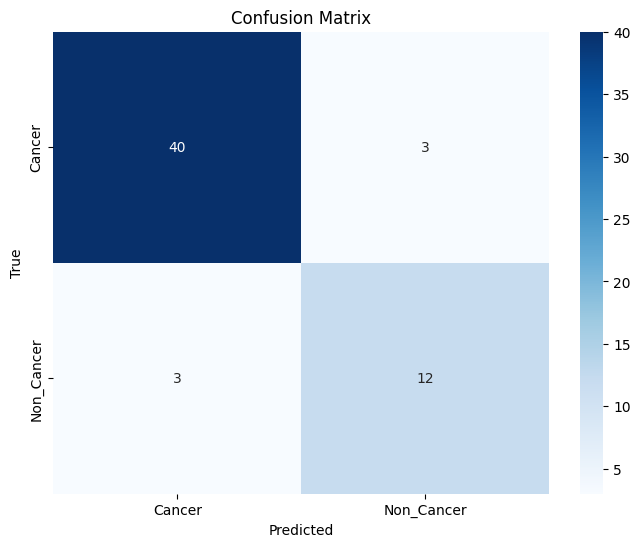

In [22]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [23]:
model.save('toa_cnn_model.h5')

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91        43
           1       0.89      0.53      0.67        15

    accuracy                           0.86        58
   macro avg       0.87      0.76      0.79        58
weighted avg       0.87      0.86      0.85        58



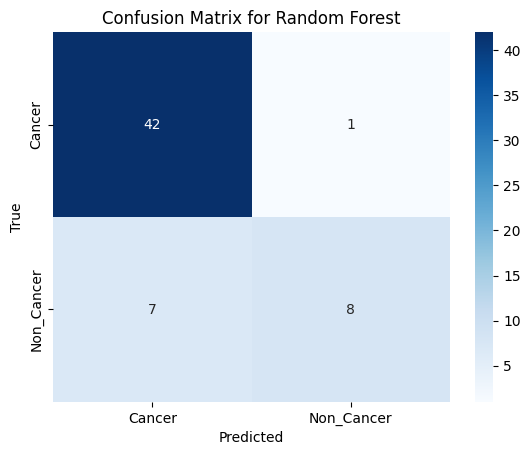

In [24]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Eğer `x` bir KerasTensor ise, tüm görüntüleri baştan NumPy array'e dönüştürmeliyiz.
x_numpy = []
for img_path in df['img']:
    img = cv2.imread(img_path)            # Görüntüyü okuma
    img = cv2.resize(img, (170, 170))    # Boyutlandırma
    img = img / 255.0                    # Normalize
    x_numpy.append(img)
x_numpy = np.array(x_numpy)

# Flatten the image data for Random Forest
x_flattened = x_numpy.reshape(x_numpy.shape[0], -1)

# Split data for Random Forest
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_flattened, y, test_size=0.2, random_state=42)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_rf, y_train_rf)

# Predict with Random Forest
y_pred_rf = rf_model.predict(x_test_rf)

# Evaluation Metrics
print("Random Forest Classification Report:")
print(classification_report(y_test_rf, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


Random Forest Results:
Accuracy: 0.8620689655172413
Precision: 0.8888888888888888
Recall: 0.5333333333333333
F1-Score: 0.6666666666666666


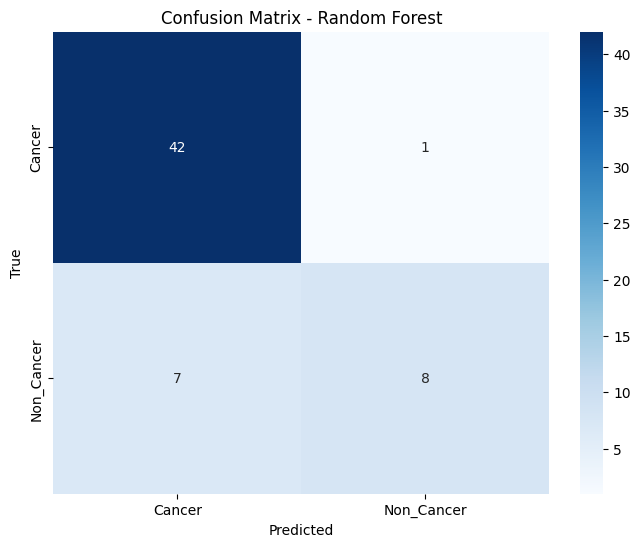

In [25]:
# Evaluation Metrics for Random Forest
rf_cm = confusion_matrix(y_test_rf, y_pred_rf)
rf_accuracy = accuracy_score(y_test_rf, y_pred_rf)
rf_precision = precision_score(y_test_rf, y_pred_rf)
rf_recall = recall_score(y_test_rf, y_pred_rf)
rf_f1 = f1_score(y_test_rf, y_pred_rf)

print("Random Forest Results:")
print(f"Accuracy: {rf_accuracy}")
print(f"Precision: {rf_precision}")
print(f"Recall: {rf_recall}")
print(f"F1-Score: {rf_f1}")

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


In [26]:
# Comparison of CNN and Random Forest
print("\nModel Comparison:")
print(f"{'Metric':<15}{'CNN':<15}{'Random Forest':<15}")
print(f"{'Accuracy':<15}{accuracy:<15.2f}{rf_accuracy:<15.2f}")
print(f"{'Precision':<15}{precision:<15.2f}{rf_precision:<15.2f}")
print(f"{'Recall':<15}{recall:<15.2f}{rf_recall:<15.2f}")
print(f"{'F1-Score':<15}{f1:<15.2f}{rf_f1:<15.2f}")



Model Comparison:
Metric         CNN            Random Forest  
Accuracy       0.90           0.86           
Precision      0.80           0.89           
Recall         0.80           0.53           
F1-Score       0.80           0.67           


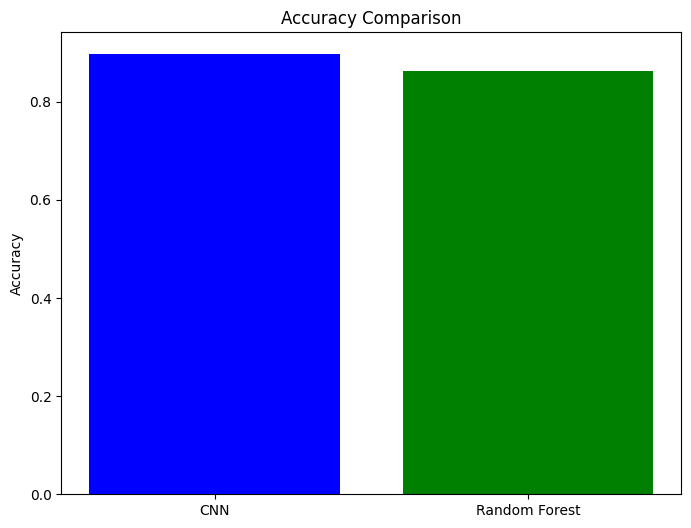

In [27]:
# Accuracy Comparison Plot
models = ['CNN', 'Random Forest']
accuracies = [accuracy, rf_accuracy]

plt.figure(figsize=(8, 6))
plt.bar(models, accuracies, color=['blue', 'green'])
plt.title('Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()


## 1 Çevrim Gösterimi

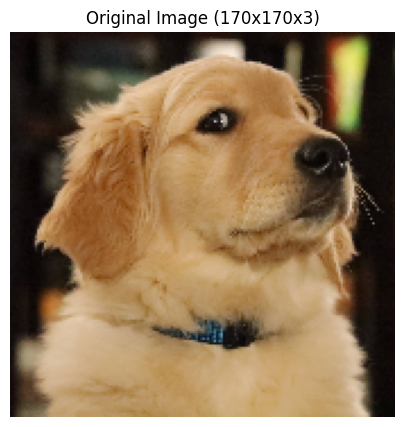

Conv2D (32 filters) Output Shape: (1, 168, 168, 32)


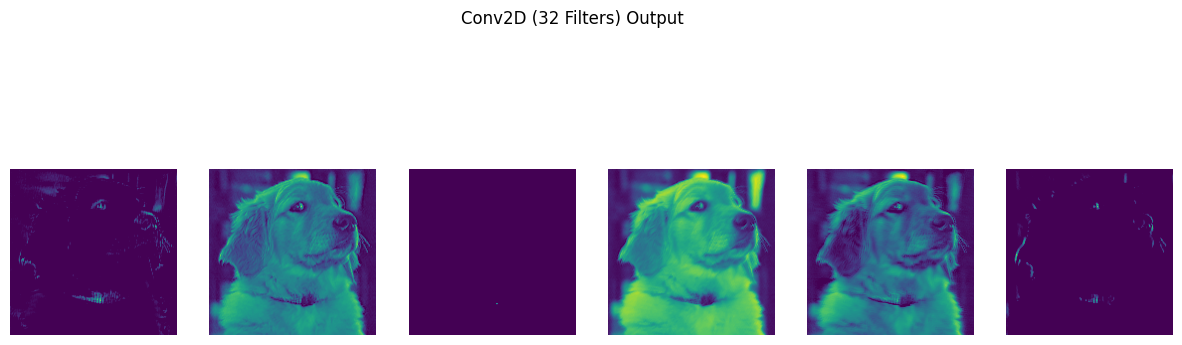

MaxPooling2D Output Shape: (1, 84, 84, 32)


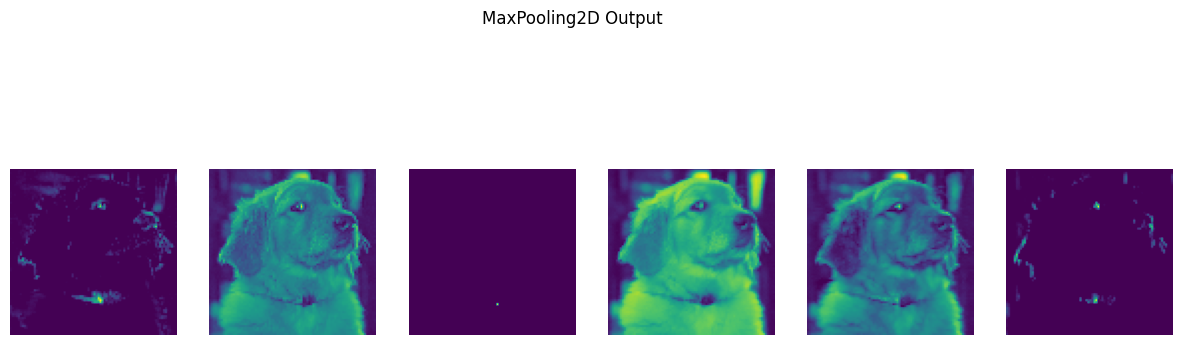

Conv2D (64 filters) Output Shape: (1, 82, 82, 64)


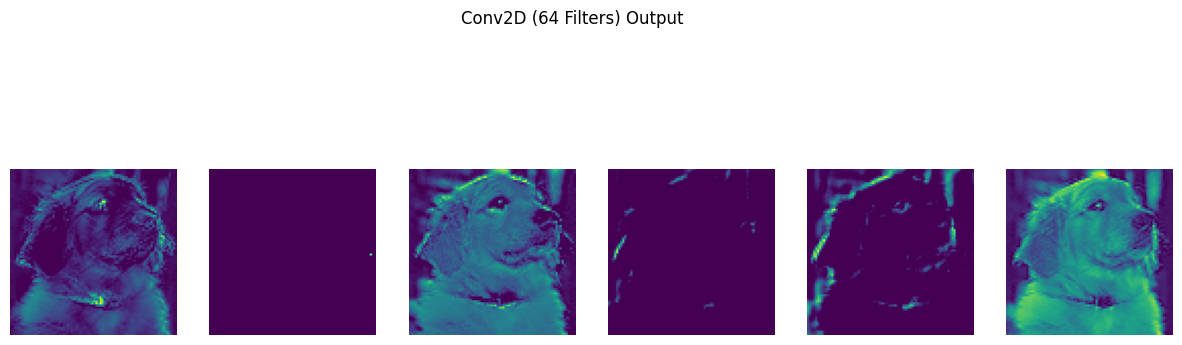

MaxPooling2D Output Shape: (1, 41, 41, 64)


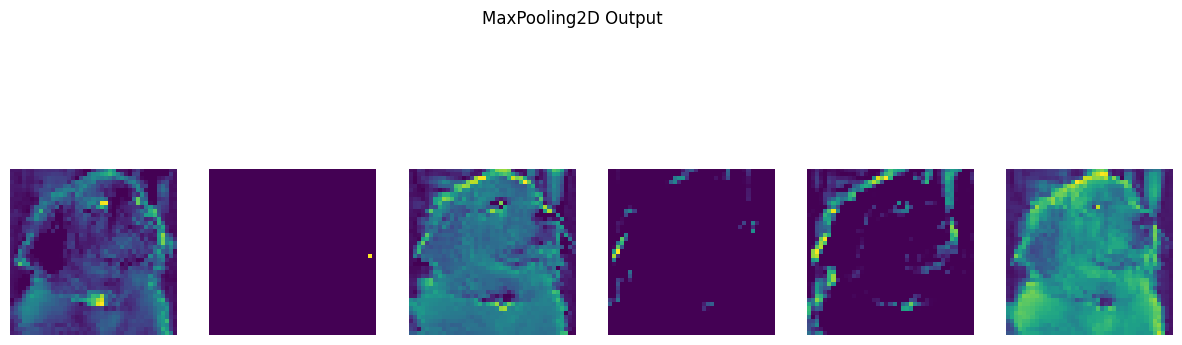

Flatten Output Shape: (1, 107584)
Dense (128 Neurons) Output Shape: (1, 128)
Dense (2 Neurons) Output Shape: (1, 2)


In [29]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Sequential

# Örnek bir görsel yükleyin
img_path = 'golden.jpg'  # Görüntü dosyasını bu yola ekleyin
img = cv2.imread(img_path)  # Görüntüyü yükle
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Renk formatını RGB'ye çevir
original_img = cv2.resize(img, (170, 170))  # Görüntüyü boyutlandır

# Normalize ve CNN girişine uygun hale getir
normalized_img = original_img / 255.0
input_image = normalized_img.reshape(1, 170, 170, 3)

# İlk halini görselleştir
plt.figure(figsize=(5, 5))
plt.imshow(original_img)
plt.title("Original Image (170x170x3)")
plt.axis('off')
plt.show()

# CNN modeli tanımla
conv1 = Conv2D(32, kernel_size=(3, 3), activation='relu')
pool1 = MaxPooling2D(pool_size=(2, 2))
conv2 = Conv2D(64, kernel_size=(3, 3), activation='relu')
pool2 = MaxPooling2D(pool_size=(2, 2))
flatten = Flatten()
dense1 = Dense(128, activation='relu')
dense2 = Dense(2, activation='softmax')

# Adım Adım Görselleştirme
current_output = input_image

# 1. Katman: Conv2D
current_output = conv1(current_output)
print("Conv2D (32 filters) Output Shape:", current_output.shape)
plt.figure(figsize=(15, 5))
for i in range(6):  # İlk 6 filtreyi görselleştir
    plt.subplot(1, 6, i + 1)
    plt.imshow(current_output[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle("Conv2D (32 Filters) Output")
plt.show()

# 2. Katman: MaxPooling2D
current_output = pool1(current_output)
print("MaxPooling2D Output Shape:", current_output.shape)
plt.figure(figsize=(15, 5))
for i in range(6):  # İlk 6 filtreyi görselleştir
    plt.subplot(1, 6, i + 1)
    plt.imshow(current_output[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle("MaxPooling2D Output")
plt.show()

# 3. Katman: Conv2D
current_output = conv2(current_output)
print("Conv2D (64 filters) Output Shape:", current_output.shape)
plt.figure(figsize=(15, 5))
for i in range(6):  # İlk 6 filtreyi görselleştir
    plt.subplot(1, 6, i + 1)
    plt.imshow(current_output[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle("Conv2D (64 Filters) Output")
plt.show()

# 4. Katman: MaxPooling2D
current_output = pool2(current_output)
print("MaxPooling2D Output Shape:", current_output.shape)
plt.figure(figsize=(15, 5))
for i in range(6):  # İlk 6 filtreyi görselleştir
    plt.subplot(1, 6, i + 1)
    plt.imshow(current_output[0, :, :, i], cmap='viridis')
    plt.axis('off')
plt.suptitle("MaxPooling2D Output")
plt.show()

# 5. Katman: Flatten
current_output = flatten(current_output)
print("Flatten Output Shape:", current_output.shape)

# 6. Katman: Dense (128 neurons)
current_output = dense1(current_output)
print("Dense (128 Neurons) Output Shape:", current_output.shape)

# 7. Katman: Dense (2 neurons)
current_output = dense2(current_output)
print("Dense (2 Neurons) Output Shape:", current_output.shape)


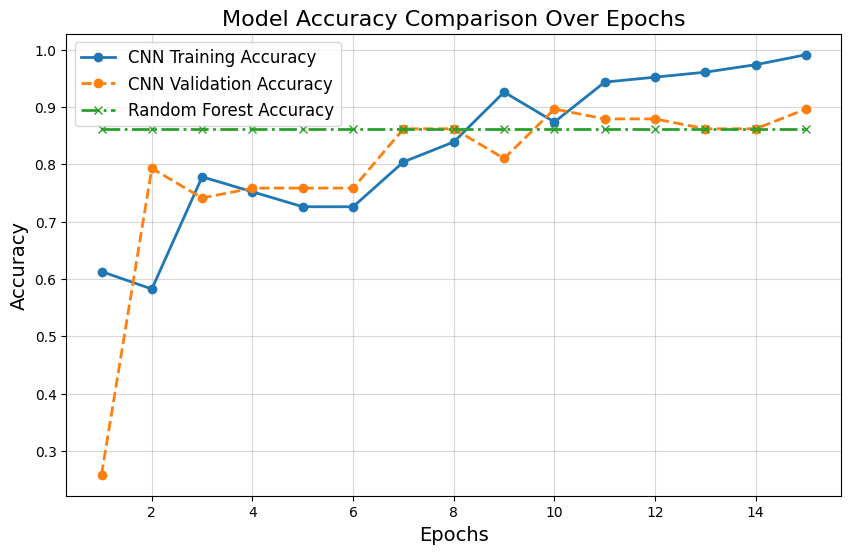

In [30]:
# Epoch bazlı CNN doğrulukları (training ve validation)
cnn_train_acc = history.history['accuracy']
cnn_val_acc = history.history['val_accuracy']

# Random Forest doğruluk değeri (aynı epoch sayısında tekrarlar ile)
rf_epochs = len(cnn_train_acc)
rf_train_acc = [rf_accuracy] * rf_epochs  # Random Forest eğitim doğruluğunu sabit kabul edelim

# Çizgi Grafiği
plt.figure(figsize=(10, 6))

# CNN doğrulukları
plt.plot(range(1, rf_epochs + 1), cnn_train_acc, label='CNN Training Accuracy', marker='o', linestyle='-', linewidth=2)
plt.plot(range(1, rf_epochs + 1), cnn_val_acc, label='CNN Validation Accuracy', marker='o', linestyle='--', linewidth=2)

# Random Forest doğrulukları
plt.plot(range(1, rf_epochs + 1), rf_train_acc, label='Random Forest Accuracy', marker='x', linestyle='-.', linewidth=2)

# Grafik ayarları
plt.title('Model Accuracy Comparison Over Epochs', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()


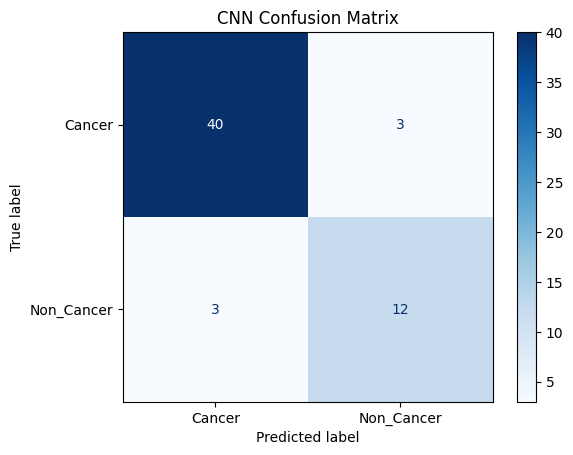

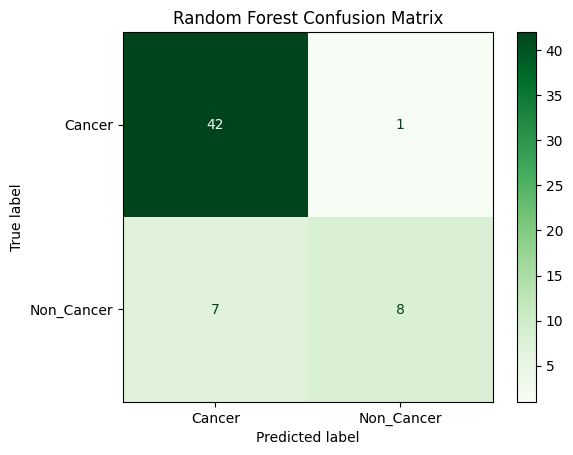

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

# CNN Confusion Matrix
ConfusionMatrixDisplay(cm, display_labels=['Cancer', 'Non_Cancer']).plot(cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.show()

# Random Forest Confusion Matrix
ConfusionMatrixDisplay(rf_cm, display_labels=['Cancer', 'Non_Cancer']).plot(cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


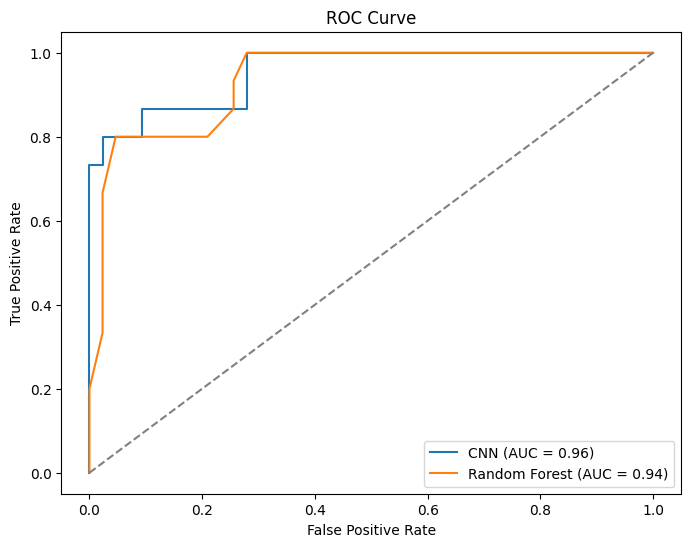

In [56]:
from sklearn.metrics import roc_curve, roc_auc_score

# CNN Tahmin Olasılıkları
cnn_probs = model.predict(x_test)
cnn_auc = roc_auc_score(y_test, cnn_probs[:, 1])

# Random Forest Tahmin Olasılıkları
rf_probs = rf_model.predict_proba(x_test_rf)[:, 1]
rf_auc = roc_auc_score(y_test_rf, rf_probs)

# ROC Eğrisi
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_probs[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN (AUC = {cnn_auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [58]:
import time

# CNN Zamanlama
start_time = time.time()
cnn_pred = model.predict(x_test)
cnn_time = time.time() - start_time

# Random Forest Zamanlama
start_time = time.time()
rf_pred = rf_model.predict(x_test_rf)
rf_time = time.time() - start_time

print(f"Prediction Time - CNN: {cnn_time:.4f} seconds")
print(f"Prediction Time - Random Forest: {rf_time:.4f} seconds")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Prediction Time - CNN: 0.4204 seconds
Prediction Time - Random Forest: 0.0467 seconds


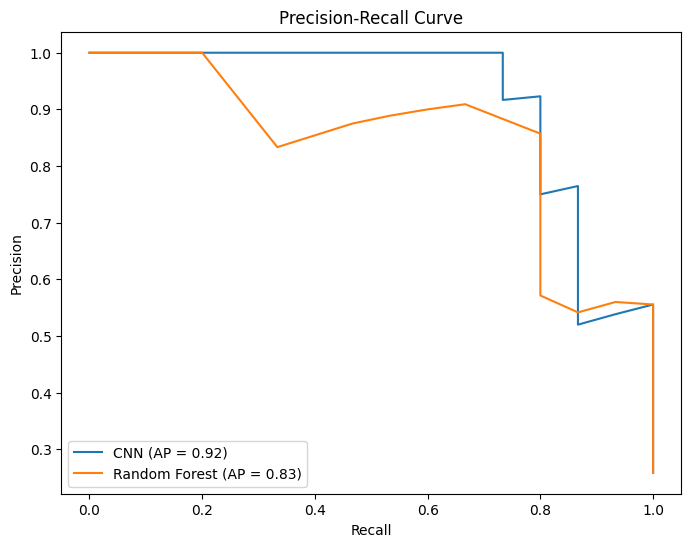

In [60]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# CNN Precision-Recall
cnn_precision, cnn_recall, _ = precision_recall_curve(y_test, cnn_probs[:, 1])
cnn_avg_precision = average_precision_score(y_test, cnn_probs[:, 1])

# Random Forest Precision-Recall
rf_precision, rf_recall, _ = precision_recall_curve(y_test_rf, rf_probs)
rf_avg_precision = average_precision_score(y_test_rf, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(cnn_recall, cnn_precision, label=f'CNN (AP = {cnn_avg_precision:.2f})')
plt.plot(rf_recall, rf_precision, label=f'Random Forest (AP = {rf_avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()
